In [1]:
# import classy module
from classy import Class

In [2]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
import numpy as np
#from plotting_utils import plot_segments



# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=True)
rc('font', family='serif', size=15)

rcParams.update({
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})

## Model parameter and argument definitions

In [3]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'tCl,pCl,lCl,mPknw','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0, 'nowiggle_pk_species':'total'})

# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()

In [4]:
# Don't use IR resummed powerspectra (yet)
use_IR_resum = 1

# galaxy bias:
b1 = np.array([1.5])
b2 = np.array([-1.])
bG2 = np.array([-0.35])
d1 = np.array([1.])
d2 = np.array([0.5])
d3 = np.array([1.])
c1_FoG = np.array([0.1])
 
# to match Dennis' noise contribution: https://arxiv.org/pdf/2204.15628 eq. 2.20

# noise bias:
n_bar = 0.000779126064152255*h**3  # Unit conversion since Dennis uses 
P_eps = np.array([1./n_bar])

k_min, k_max = 5e-3, 0.2
z = np.array([0.8])
n_z = len(z)

In [5]:
def make_k_array_np_log(k_min, k_max, n_steps, *, keep_valid_triangles=True):
    """
    Return all i<=j<=k triples of logarithmically spaced k values
    between k_min and k_max.  Optionally drop the ones that violate
    the triangle inequality.

    Parameters
    ----------
    k_min, k_max : float
        Interval limits (k_min < k_max).
    n_steps      : int
        Number of grid points per axis.
    keep_valid_triangles : bool, default True
        If True, only keep triples that fulfil  k1 + k2 >= k3.
    """
    # 1) build index grid
    I, J, K = np.indices((n_steps,) * 3)

    # 2) retain i <= j <= k
    mask = (I <= J) & (J <= K)
    ijk  = np.stack((I[mask], J[mask], K[mask]), axis=1)       # (N, 3)

    # 3) logarithmic mapping  k = k_min * R**index
    R = (k_max / k_min) ** (1.0 / (n_steps - 1))
    k_triplets = k_min * R ** ijk                               # (N, 3)

    if keep_valid_triangles:
        # with k1 <= k2 <= k3 only this test is needed
        tri_mask = (k_triplets[:, 0] + k_triplets[:, 1]) >= k_triplets[:, 2]
        k_triplets = k_triplets[tri_mask]


    # guarantee C-contiguous float64 memory for the Cython wrapper
    return np.ascontiguousarray(k_triplets, dtype=np.float64)

k_min, k_max, n_steps = 5e-3, 0.2, 40
triangles = make_k_array_np_log(k_min, k_max, n_steps, keep_valid_triangles=True)  # C-contiguous float64

print(triangles.shape[0])

triangle_bug = np.array([1,1,3], dtype=np.float64)*1e-02 # This does not satisfy the triangle inequality on purpose to test whether error handling works well.

2998


In [6]:
# Make the AP factors
D_A_fid = 1663.9307801326001
H_fid = 0.00037966933846752485

h = LambdaCDM.h()
H = np.zeros(n_z, 'float64')
D_A = np.zeros(n_z, 'float64')
for i in range(n_z):
    D_A[i] = LambdaCDM.angular_distance(z[i]) # in Mpc
    H[i]   = LambdaCDM.Hubble(z[i])           # in (Mpc)^(-1)

#Alcock Pacinsky effect
q_orth = D_A/D_A_fid  # 1/f_orth  # alpha_perp
q_parr = H_fid/H                  # alpha_parallel

print(q_orth, q_parr)

q_orth = np.ones(n_z, dtype=np.float64)
q_parr = np.ones(n_z, dtype=np.float64)


[0.96049212] [1.065076]


## Test against Fynns function

In [7]:
import time as t
t_start = t.perf_counter()
B_l = LambdaCDM.bispectrum_treelevel_multipoles_AP_FoG(
                                                       1,
                                                       b1,
                                                       b2,
                                                       bG2,
                                                       d1,
                                                       d2,
                                                       d3,
                                                       P_eps,
                                                       c1_FoG,
                                                       triangles,
                                                       z,
                                                       4,
                                                       q_orth,
                                                       q_parr
)
t_end = t.perf_counter()
print(t_end-t_start)

0.12410007504513487


In [8]:
B_l_Fynn = np.zeros((n_z, 3, triangles.shape[0]), dtype=np.float64)

t_start_Fynn = t.perf_counter()
for zi in range(n_z):
    for i in range(triangles.shape[0]):
        for l in range(3):
            ell = 2*l

            B_l_Fynn[zi, l, i] = LambdaCDM.bk_lin_multipoles(1,
                                                             b1[zi],
                                                             b2[zi],
                                                             bG2[zi],
                                                             d1[zi],
                                                             d2[zi],
                                                             d3[zi],
                                                             P_eps[zi],
                                                             c1_FoG[zi],
                                                             triangles[i,0],
                                                             triangles[i,1],
                                                             triangles[i,2],
                                                             ell,
                                                             z[zi])
            
t_end_Fynn = t.perf_counter()
            
# for zi in range(n_z):
#     for i in range(triangles.shape[0]):
#         B_l_Fynn[zi, 0, i] = LambdaCDM.bk_lin_multipoles(1,
#                                                          b1[zi],
#                                                          b2[zi],
#                                                          bG2[zi],
#                                                          d1[zi],
#                                                          d2[zi],
#                                                          d3[zi],
#                                                          P_eps[zi],
#                                                          c1_FoG[zi],
#                                                          triangles[i,0],
#                                                          triangles[i,1],
#                                                          triangles[i,2],
#                                                          0,
#                                                          z[zi])

print(t_end_Fynn-t_start_Fynn)

0.8165964540094137


True


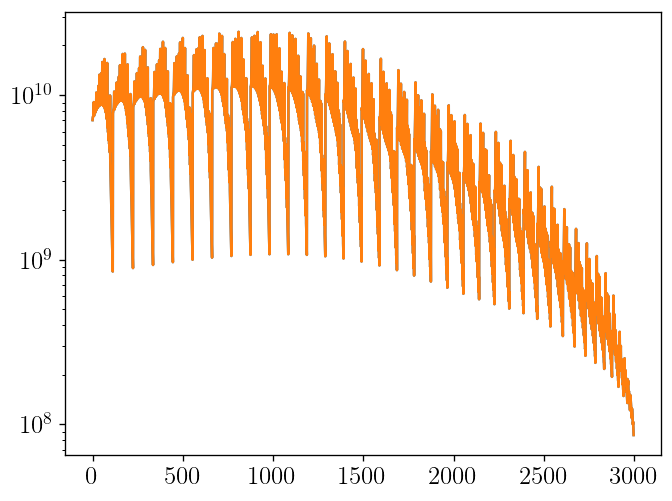

In [9]:
print(np.array_equal(B_l, B_l_Fynn))

plt.plot(B_l[0,0,:])
plt.plot(B_l_Fynn[0,0,:])
plt.yscale("log")
plt.show()

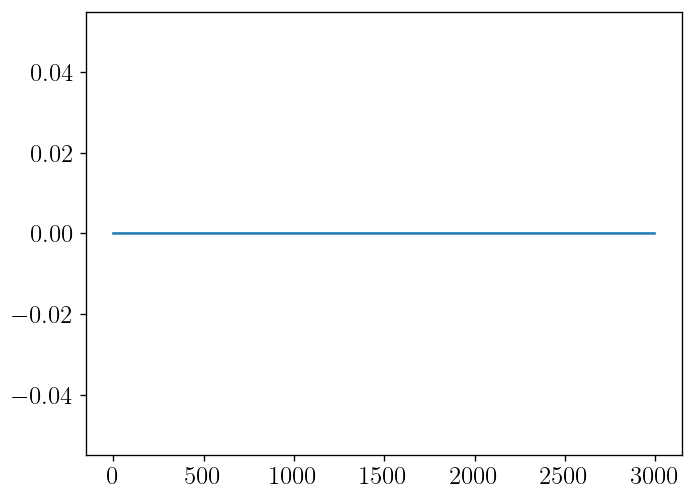

In [10]:
plt.plot(np.abs(B_l[0,0,:]-B_l_Fynn[0,0,:]))
plt.show()

## Computation Time Bottleneck

### Timing with power spectra outside of for loop:

0.85 seconds

### Timing with power spectra inside of for loop:

0.65 seconds (1D interpolation)

In [11]:
t_start = t.perf_counter()
B_l = LambdaCDM.bispectrum_treelevel_multipoles_AP_FoG(
                                                       1,
                                                       b1,
                                                       b2,
                                                       bG2,
                                                       d1,
                                                       d2,
                                                       d3,
                                                       P_eps,
                                                       c1_FoG,
                                                       triangles,
                                                       z,
                                                       2,
                                                       q_orth,
                                                       q_parr
)
t_end = t.perf_counter()
print(t_end-t_start)

0.11098841897910461


### Timing for Mono + Quadrupole for array_interpolate_spline and 3000 triangles

0.48 seconds

### Timing for Mono + Quadrupole for array_interpolate_spline_growing_closeby and 3000 triangles

0.39 seconds

### Timing for Mono + Quadrupole for array_interpolate_spline_growing_hunt and 3000 triangles

0.37 seconds

## Fynns comparison with Dennis

AttributeError: 'classy.Class' object has no attribute 'get_bk_lin_multipoles_configs'

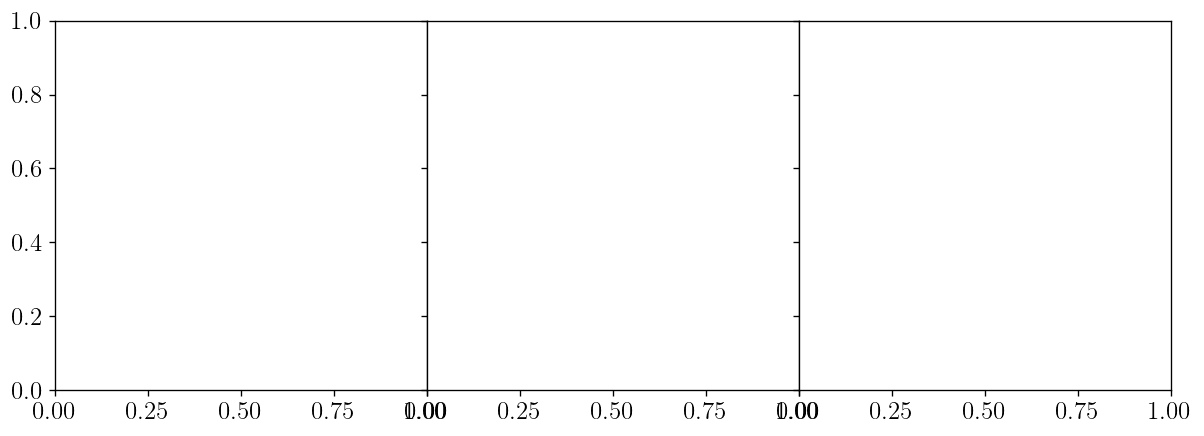

In [12]:
triangle_types = ["equi", "iso", "squeezed"]        # 3 types of triangle configs that we are interest in

# multipole l
l_s = [0, 2, 4]
labels = ["Monopole", "Quadrupole", "Hexadecapole"]
colors = ["tab:red", "tab:blue", "tab:green"]
ls = ["solid", "dashed", "dotted"]


#fig, ax = plt.subplots(3, 1, figsize=(7, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1], 'hspace': 0})

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True, gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0})

dx = 0.02
idx = 0
use_labels= True
for z_ in z:
    for type in triangle_types:
        for l_idx, l in enumerate(l_s):
            Bk_l = LambdaCDM.get_bk_lin_multipoles_configs(use_IR_resum, b1, b2, bG2, d1, d2, d3, P_eps, type, k, l, z, k_size, z_size)
            Bk_l_1D = Bk_l[:, 0]
            plot_segments(ax[idx], k/h, Bk_l_1D*h**6, colors[l_idx], rf"{labels[l_idx]}", "solid", use_labels)
            #ax[idx].plot(k/h, Bk_l_1D*h**6)
        use_labels = False
        ax[idx].set_xscale("log")
        ax[idx].set_yscale("log")
        ax[idx].set_xlabel(rf"$k$ $\left[h/\mathrm{{Mpc}}\right]$")
        if type == "equi":
            ax[idx].set_ylabel(rf"$B_\ell(k_1, k_2, k_3, z={z_})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$")
            # Add title for equilateral
            ax[idx].annotate("$k=k_1=k_2=k_3$", xy=(dx, 0.94), xycoords="axes fraction", ha="left", fontsize=15)
            ax[idx].set_title("Equilateral")
        elif type == "iso":
            #ax[idx].set_ylabel(rf"$B_\ell(k, 2k, 2k, z={z_})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$")
            # Add title for isosceles
            ax[idx].annotate("$k=k_1=k_2=2k_3$", xy=(dx, 0.94), xycoords="axes fraction", ha="left", fontsize=15)
            ax[idx].set_title("Isosceles")
        elif type == "squeezed":
            #ax[idx].set_ylabel(rf"$B_\ell(k, k, k/10, z={z_})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$")
            # Add title for squeezed
            ax[idx].annotate("$k=k_1=k_2=10k_3$", xy=(dx, 0.94), xycoords="axes fraction", ha="left", fontsize=15)
            ax[idx].set_title("Squeezed")

        ax[idx].set_ylim(1e4, 1.e10)
        ax[idx].set_xlim(8e-4, k_max)
        idx += 1
fig.legend(loc='center', bbox_to_anchor=(0.5, -0.005), ncol=3)

plt.tight_layout()
plt.savefig(f"bispectrum_multipoles_configs.pdf", bbox_inches='tight')
plt.show()






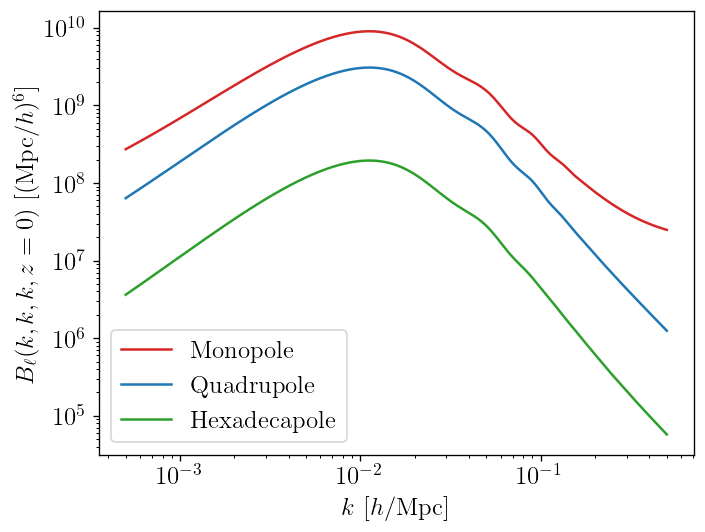

In [ ]:
triangle_types = ["equi", "iso", "squeezed"]        # 3 types of triangle configs that we are interest in

# multipole l
l_s = [0, 2, 4]
labels = ["Monopole", "Quadrupole", "Hexadecapole"]
colors = ["tab:red", "tab:blue", "tab:green"]
ls = ["solid", "dashed", "dotted"]


#fig, ax = plt.subplots(3, 1, figsize=(7, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1], 'hspace': 0})


dx = 0.02
idx = 0
use_labels= True

for idx, l in enumerate(l_s):
    Bk_l = LambdaCDM.get_bk_lin_multipoles_configs(use_IR_resum, b1, b2, bG2, d1, d2, d3, P_eps, "equi", k, l, z, k_size, z_size)
    Bk_l_1D = Bk_l[:, 0]
    plt.plot(k, Bk_l_1D, label=labels[idx], color=colors[idx])
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$B_\ell(k, k, k, z=0)$ $[(\mathrm{{Mpc}}/h)^6]$")
plt.xlabel(r"$k$ $[h/\mathrm{{Mpc}}]$")
plt.legend()
plt.savefig("bispectrum_single_showcase.pdf", bbox_inches='tight')